In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import NullFormatter
from matplotlib.patches import Rectangle
import datetime as dt
import pandas as pd

%matplotlib inline

In [2]:
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41047,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32839,Total threads: 2
Dashboard: /proxy/44123/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:45307,


2026-03-09 15:09:45,265 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1)->('array-broadcast_to-concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1))
new run_spec: Alias(('concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1)->('broadcast_to-concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1))
old dependencies: {('array-broadcast_to-concatenate-bc22e0ce18169dcc7cb26c08843aa3b2', 1)}
new dependencies: frozenset({('broadcast_to-concatenate-bc22e0ce18169dcc

### Select region and time period of interest

In [3]:
# deal with the discontinuity in the OM2 grid with a helper function so that can use nromal oongitude values below
def map_lon_to_ds(lon_e, lon_coord_min=-280.0, lon_coord_max=80.0):
    lonmin = lon_coord_min
    lonmax = lon_coord_max
    if 0.0 <= lonmin and lonmax <= 360.0:
        return lon_e % 360.0
    if -180.0 <= lonmin and lonmax <= 180.0:
        return ((lon_e + 180.0) % 360.0) - 180.0
    if lonmax <= 100.0 and lonmin < -180.0:  # ACCESS-style
        return lon_e if lon_e <= lonmax else lon_e - 360.0
    return lon_e

In [4]:
# Region to load (wider region for plotting with context):
#reg = [-100, 20, 0, 70] # North Atlantic
#reg = [-100, -40, 0, 30] # North Atlantic
#reg = [map_lon_to_ds(135), map_lon_to_ds(175), -60, -20] # Tasman Sea 2017/18
reg = [map_lon_to_ds(100), map_lon_to_ds(120), -40, -15] # WA 2011
#reg = [map_lon_to_ds(280), map_lon_to_ds(360), 30, 80] # NW atlantic 2012


# Region to load (exact box of MHW):
#sreg = [map_lon_to_ds(150), map_lon_to_ds(168), -44, -38]# Tasman Sea 2017/18
sreg = [map_lon_to_ds(110), map_lon_to_ds(116), -32, -25]# # WA 2011
#sreg = [map_lon_to_ds(112.5), map_lon_to_ds(116), -31, -25]# # WA 2011 coastal
#sreg = [map_lon_to_ds(290), map_lon_to_ds(325), 45, 55] # NW atlantic 2012

# time period to load
#t0, t1 = '2017-11-01', '2018-03-01' # Tasman Sea 2017/18
t0, t1 = '2011-02-01', '2011-06-01' # WA 2011
#t0, t1 = '2012-01-10', '2013-03-31' # NW atlantic 2012

#set base path:
base = '/g/data/av17/access-nri/OM2/025deg_jra55_iaf_cycle6_online_mlt/'  

# Chunks to use:
chunks2D = {'time':1,'yt_ocean':216,'xt_ocean':240}
chunks3D = {'time':1,'st_ocean':25,'yt_ocean':324,'xt_ocean':360}

### Plot region on map for context

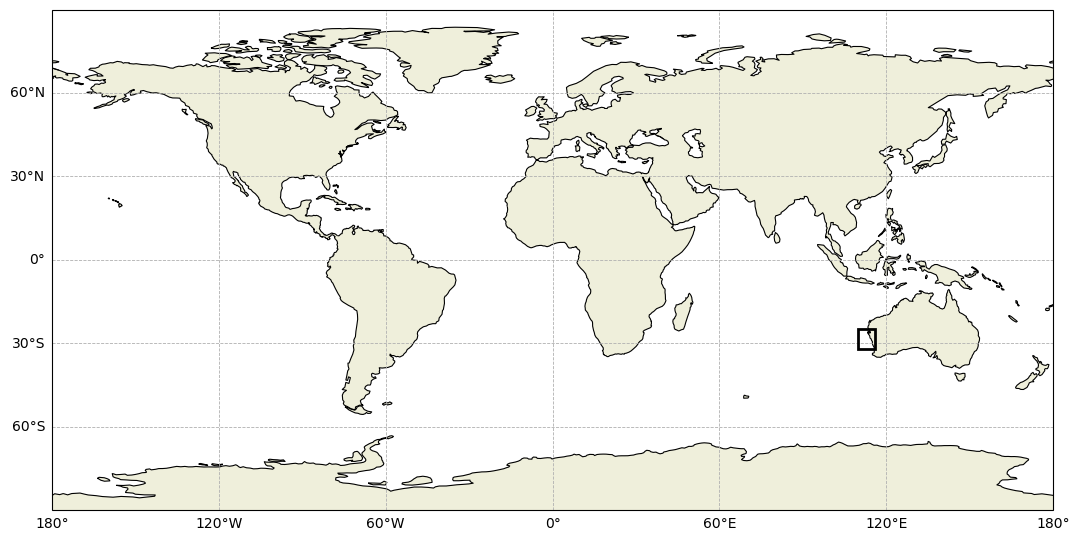

In [5]:
fig = plt.figure(figsize=(13, 6.5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# Context layers
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)

# Gridlines + labels
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# Bounding box
rect = Rectangle(
    (sreg[0], sreg[2]),
    sreg[1] - sreg[0],
    sreg[3] - sreg[2],
    fill=False,
    linewidth=2,
    transform=ccrs.PlateCarree(),
    zorder=3,
)
ax.add_patch(rect)

### load mixed layer temperature for the appropriate years

In [6]:
# Choose years to consider (ACCESS output numbers)
#outputs = [364, 365]   # 2017, 2018
outputs = [358]   # 2011
#outputs = [364]  # 2000-2018
#outputs = [359,360]  # 2012-2013

# Create list of file paths for all outputs
base2 = [base + f'output{o:03d}/ocean/ocean_daily.nc' for o in outputs]

ds_day = xr.open_mfdataset(
    base2, 
    decode_times=True,
    chunks=chunks2D,
    combine='nested',
    concat_dim='time',
    data_vars=['mld', 'temp_in_mld'],
    parallel=True,
).sel(xt_ocean=slice(reg[0],reg[1]), yt_ocean=slice(reg[2],reg[3]))

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/_task_spec.py:758: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return self.func(*new_argspec, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/dask/_task_spec.py:758: FutureWarning: In a future version, xarray will not decode the variable 'time_bounds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by de

In [7]:
ds_day

<xarray.Dataset> Size: 5GB
Dimensions:                (time: 365, yt_ocean: 114, xt_ocean: 80,
                            yu_ocean: 1080, xu_ocean: 1440, nv: 2)
Coordinates:
  * time                   (time) datetime64[ns] 3kB 2010-12-30T12:00:00 ... ...
  * yt_ocean               (yt_ocean) float64 912B -39.93 -39.74 ... -15.19
  * xt_ocean               (xt_ocean) float64 640B -259.9 -259.6 ... -240.1
  * yu_ocean               (yu_ocean) float64 9kB -81.02 -80.92 ... 89.89 90.0
  * xu_ocean               (xu_ocean) float64 12kB -279.8 -279.5 ... 79.75 80.0
  * nv                     (nv) float64 16B 1.0 2.0
Data variables: (12/24)
    surface_temp           (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    sss                    (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    mld                    (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    temp_in_mld            (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    temp_at_mlb            (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    salt_in_mld            (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    ...                     ...
    sfc_hflux_from_runoff  (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    sfc_hflux_pme          (time, yt_ocean, xt_ocean) float32 13MB dask.array<chunksize=(1, 109, 80), meta=np.ndarray>
    average_T1             (time) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    average_T2             (time) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    average_DT             (time) timedelta64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    time_bounds            (time, nv) timedelta64[ns] 6kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    filename:   ocean_daily.nc
    title:      ACCESS-OM2
    grid_type:  mosaic
    grid_tile:  1
    history:    20251118T0744Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

### load clim and thresholds

In [8]:
thresh = xr.open_dataset(base + 'post_processed_diags/om2_025_MLT_thresh.nc').sel(xt_ocean=slice(reg[0],reg[1]), yt_ocean=slice(reg[2],reg[3]))
clim = xr.open_dataset(base + 'post_processed_diags/om2_025_MLT_clim.nc').sel(xt_ocean=slice(reg[0],reg[1]), yt_ocean=slice(reg[2],reg[3]))

#simplify temp_in_mld to temp
temp = ds_day.temp_in_mld.to_dataset(name='temp')/1035

### Select region and time period of interest for the MHW analysis

In [9]:
clim_box   = clim.temp.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3]))
thresh_box = thresh.temp.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3]))
temp_box   = temp.sel(time=slice(t0,t1)).temp.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3]))
mld_box    = ds_day.mld.sel(time=slice(t0,t1)).sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3]))

# pre-compute means
clim_mean = clim_box.mean(dim=('xt_ocean', 'yt_ocean')).compute()
thresh_mean = thresh_box.mean(dim=('xt_ocean', 'yt_ocean')).compute()
temp_mean = temp_box.sel(time=slice(t0,t1)).mean(dim=('xt_ocean', 'yt_ocean'))
mld_mean = mld_box.mean(dim=('xt_ocean', 'yt_ocean')).compute()

#### Check threshold and mean climatology

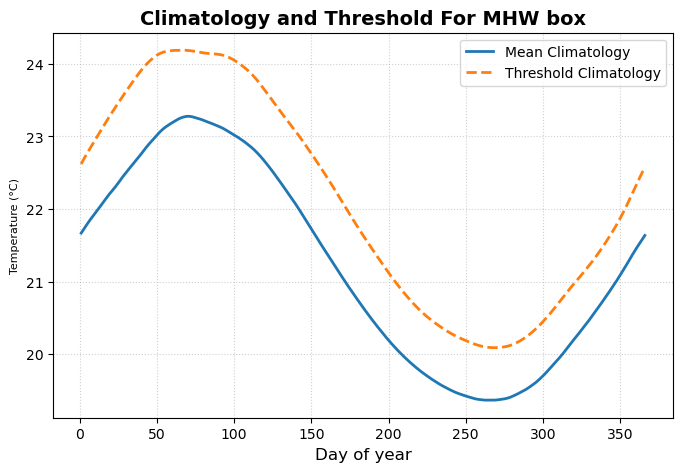

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

clim_mean.plot(ax=ax, label='Mean Climatology', color='C0', linewidth=2)
thresh_mean.plot(ax=ax, label='Threshold Climatology', color='C1', linewidth=2, linestyle='--')

ax.set_title('Climatology and Threshold For MHW box', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of year', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=8)
ax.legend(fontsize=10, loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

### Automatically identify and annotate the onset, peak, and end of the MHW
* if you get multiple peaks for your time period of interest, increase MAX_GAP from the default 2 days or shorten your time period

/jobfs/162592549.gadi-pbs/ipykernel_2402902/1121194435.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lab = (long_true.diff(1).fillna(False) | (~long_true).shift(1, fill_value=False) & long_true).cumsum()


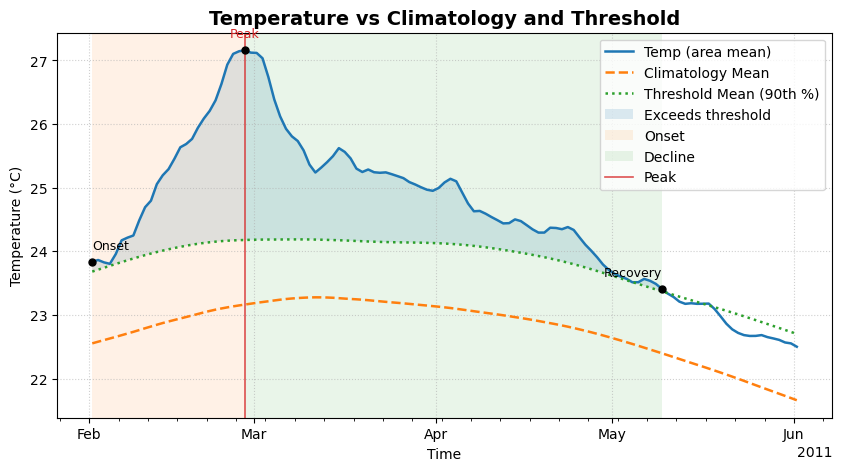

In [11]:
# index the day of year axis of clim and thresh onto the time of the interannually varying mixed layer temperature---
doy = temp_mean['time'].dt.dayofyear
clim_on_time   = clim_mean.sel(dayofyear=doy)
thresh_on_time = thresh_mean.sel(dayofyear=doy)

# --- plot the timeseries + threshold/clim ---
fig, ax = plt.subplots(figsize=(10, 5))
temp_mean.plot(ax=ax, label='Temp (area mean)', linewidth=1.8)
clim_on_time.plot(ax=ax, label='Climatology Mean', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax, label='Threshold Mean (90th %)', linewidth=1.8, linestyle=':')

# --- shaded exceedances ---
t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
valid  = np.isfinite(y_temp) & np.isfinite(y_thr)
ax.fill_between(t[valid], y_thr[valid], y_temp[valid],
                where=(y_temp[valid] > y_thr[valid]), alpha=0.15, label='Exceeds threshold')

# ---------- PHASE DETECTION & ANNOTATION ----------
import pandas as pd

# Parameters for Hobday-style event definition
MIN_DUR = 5     # minimum duration (days)
MAX_GAP = 2     # merge gaps <= 2 days

time_idx = pd.to_datetime(t[valid])
exceed   = (y_temp[valid] > y_thr[valid])
series   = pd.Series(exceed, index=time_idx).astype(int)

# Merge short gaps: any False-runs of length <= MAX_GAP become True
runs = (series.diff(1).ne(0)).cumsum()
run_lengths = series.groupby(runs).transform('size')
is_false_run = (series == 0)
short_false  = is_false_run & (run_lengths <= MAX_GAP)
series_merged = series.copy()
series_merged[short_false] = 1

# Recompute runs on merged series and pick only True-runs with length >= MIN_DUR
runs2 = (series_merged.diff(1).ne(0)).cumsum()
lens2 = series_merged.groupby(runs2).transform('size')
is_true_run = (series_merged == 1)
long_true   = is_true_run & (lens2 >= MIN_DUR)

# Extract contiguous event segments
events = []
if long_true.any():
    lab = (long_true.diff(1).fillna(False) | (~long_true).shift(1, fill_value=False) & long_true).cumsum()
    # Simpler: iterate over contiguous blocks where long_true is True
    start_i = None
    arr = long_true.to_numpy()
    idx = long_true.index.to_numpy()
    for i in range(len(arr)):
        if arr[i] and start_i is None:
            start_i = i
        if start_i is not None and (i == len(arr)-1 or not arr[i+1]):
            # end of block at i
            s, e = start_i, i
            events.append((idx[s], idx[e]))
            start_i = None

# Annotate each event with phases
anom = (y_temp[valid] - y_thr[valid])
anom_series = pd.Series(anom, index=time_idx)

for k, (t_start, t_end) in enumerate(events, start=1):
    # Peak = time of maximum anomaly within event
    seg = anom_series.loc[t_start:t_end]
    t_peak = seg.idxmax()

    # Visual spans for phases
    ax.axvspan(t_start, t_peak, alpha=0.10, facecolor='tab:orange', label='Onset' if k == 1 else None)
    ax.axvspan(t_peak,  t_end,  alpha=0.10, facecolor='tab:green',  label='Decline' if k == 1 else None)

    # Markers + thin lines down to curve
    ax.axvline(t_peak, color='tab:red', linestyle='-', linewidth=1.2, alpha=0.8,
               label='Peak' if k == 1 else None)
    ax.scatter([t_start, t_peak, t_end],
               [temp_mean.sel(time=t_start).values.item(),
                temp_mean.sel(time=t_peak).values.item(),
                temp_mean.sel(time=t_end).values.item()],
               s=25, zorder=5, color='k')

    # Text labels (nudged)
    y0 = temp_mean.sel(time=t_start).values.item()
    y1 = temp_mean.sel(time=t_peak).values.item()
    y2 = temp_mean.sel(time=t_end).values.item()
    ax.text(t_start, y0 + 0.15, 'Onset', fontsize=9, ha='left', va='bottom')
    ax.text(t_peak,  y1 + 0.15, 'Peak',  fontsize=9, ha='center', va='bottom', color='tab:red')
    ax.text(t_end,   y2 + 0.15, 'Recovery', fontsize=9, ha='right', va='bottom')

# ---------- formatting ----------
ax.set_title('Temperature vs Climatology and Threshold', fontsize=14, fontweight='bold')
ax.set_xlabel('Time'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best'); ax.grid(True, linestyle=':', alpha=0.6)

locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_minor_formatter(NullFormatter())

### define function to plot spatial maps


In [12]:
def plotmap(data, ax=None, extent=None, lon_name='xt_ocean', lat_name='yt_ocean'):
    """Simple Cartopy map (regional), using given coord names."""
    if ax is None:
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(6, 4.5))
    else:
        fig = None

    lon = np.asarray(data[lon_name])
    lat = np.asarray(data[lat_name])
    if extent is None:
        extent = [float(np.nanmin(lon)), float(np.nanmax(lon)),
                  float(np.nanmin(lat)), float(np.nanmax(lat))]

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.9', edgecolor='none')
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    return fig, ax


### load budget terms and mld climatology

In [13]:
# Create list of file paths for budget outputs
budget_files = [base + f'post_processed_diags/mlt_budget_online_stavg/mlt_budget_stavg_daily_online_output{o:03d}.nc' for o in outputs]

budget = xr.open_mfdataset(
    budget_files,
    decode_times=True,
    chunks=chunks2D,
    combine='nested',
    concat_dim='time',
    parallel=True
).sel(xt_ocean=slice(reg[0],reg[1]), yt_ocean=slice(reg[2],reg[3]))

In [25]:
budget_clim = xr.open_dataset(base+'post_processed_diags/mlt_budget_online_stavg/mlt_budget_stavg_daily_online_output336-365_monthly_mean.ncea.nc')
mld_clim = xr.open_dataset(base+'post_processed_diags/ocean_month_output336-365.clim.nc').mld.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3]))

In [28]:
mld_clim=mld_clim.mean(['yt_ocean', 'xt_ocean'])

### Subset budget terms and turn into a nice clean dataset

In [16]:
# --- region of interest in ACCESS-OM grid convention ---
lon_min_ds, lon_max_ds, lat_min, lat_max = sreg

# --- select region & needed variables ---
vars_needed = [
    'mlt_tendency','advection','vert_mixing','entrainment',
    'surface_flux','sw_pen','residual'
]
budget = budget[vars_needed].sel(
    xt_ocean=slice(lon_min_ds, lon_max_ds),
    yt_ocean=slice(lat_min, lat_max)
).chunk({'time': -1})   # make time a single chunk for rolling

# --- derived term: surface flux absorbed in mixed layer ---
budget['surf_to_ML_absorbed'] = budget['surface_flux'] + budget['sw_pen']

# --- area-weighted mean (cos(lat)) over box ---
w = np.cos(np.deg2rad(budget['yt_ocean']))
box_series = xr.Dataset({
    'MLT tendency'       : budget['mlt_tendency'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Surface Flux': budget['surf_to_ML_absorbed'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Advection'          : budget['advection'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Vertical mixing'    : budget['vert_mixing'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Entrainment'        : budget['entrainment'].weighted(w).mean(('yt_ocean','xt_ocean')),
    'Residual'           : budget['residual'].weighted(w).mean(('yt_ocean','xt_ocean')),
})

# convert from deg per second to deg per day
SEC_PER_DAY = 86400.0
vars_to_convert = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment','Residual']

for v in vars_to_convert:
    if v in box_series:
        box_series[v] = (box_series[v] * SEC_PER_DAY).assign_attrs(
            {**box_series[v].attrs, 'units': 'degC day-1'}
        )

# (optional) record provenance on the Dataset
hist = box_series.attrs.get('history', '')
box_series = box_series.assign_attrs(
    history = (hist + '\nConverted from degC s-1 to degC day-1 (×86400).')
)

#Load dataset for quicker plotting (will take a minute or two depending on the size of your domain)
box_series.compute()

<xarray.Dataset> Size: 20kB
Dimensions:          (time: 365)
Coordinates:
  * time             (time) datetime64[ns] 3kB 2011-01-01T12:00:00 ... 2011-1...
Data variables:
    MLT tendency     (time) float64 3kB 0.02391 0.2193 ... 0.01015 0.008676
    Surface Flux     (time) float64 3kB 0.07551 0.2155 ... 0.06038 0.06123
    Advection        (time) float64 3kB 0.02056 0.05085 ... -0.003397 -0.003082
    Vertical mixing  (time) float64 3kB -0.06458 -0.08305 ... -0.03534 -0.03488
    Entrainment      (time) float64 3kB -0.007589 0.03594 ... -0.01149 -0.01459
    Residual         (time) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    history:  \nConverted from degC s-1 to degC day-1 (×86400).

## Subset budget climatologies:

In [17]:
# --- subset budget_clim to the box and keep only needed vars ---
clim_box = budget_clim[vars_needed].sel(
    xt_ocean=slice(lon_min_ds, lon_max_ds),
    yt_ocean=slice(lat_min,     lat_max)
)

# --- area weights (cos(lat)) ---
w = np.cos(np.deg2rad(clim_box['yt_ocean']))

# --- monthly, area-mean fields over the box ---
clim_monthly = xr.Dataset({
    'MLT tendency' : clim_box['mlt_tendency']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Surface Flux' : (clim_box['surface_flux'] + clim_box['sw_pen']).weighted(w).mean(('yt_ocean','xt_ocean')),
    'Advection'    : clim_box['advection']          .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Vertical mixing': clim_box['vert_mixing']      .weighted(w).mean(('yt_ocean','xt_ocean')),
    'Entrainment'  : clim_box['entrainment']        .weighted(w).mean(('yt_ocean','xt_ocean')),
})

# Optional: ensure 'time' is a single chunk for later groupby/interp
clim_monthly = clim_monthly.chunk({'time': -1})

SEC_PER_DAY = 86400.0
vars_to_convert = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment']  # add 'Residual' if you include it

for v in vars_to_convert:
    clim_monthly[v] = (clim_monthly[v] * SEC_PER_DAY).assign_attrs(
        {**clim_monthly[v].attrs, 'units': 'degC day-1'}
    )

# (optional) provenance
clim_monthly = clim_monthly.assign_attrs(
    history=(clim_monthly.attrs.get('history','') + '\nConverted from degC s-1 to degC day-1 (×86400).')
)

#Load dataset for quicker plotting (should be quick)
clim_monthly.compute()

<xarray.Dataset> Size: 576B
Dimensions:          (time: 12)
Coordinates:
  * time             (time) datetime64[ns] 96B 1989-01-16T12:00:00 ... 1989-1...
Data variables:
    MLT tendency     (time) float64 96B 0.0294 0.02641 ... 0.0279 0.03296
    Surface Flux     (time) float64 96B 0.1449 0.127 0.03825 ... 0.1147 0.1381
    Advection        (time) float64 96B 0.0005346 0.009885 ... 0.0004142
    Vertical mixing  (time) float64 96B -0.1035 -0.09844 ... -0.07034 -0.09025
    Entrainment      (time) float64 96B -0.01258 -0.01202 ... -0.01872 -0.01532
Attributes:
    history:  \nConverted from degC s-1 to degC day-1 (×86400).

### Prepare input data for plotting
* set up plotting domain order and colours
* smooth temperature
* interpolate monthly budget climatology to daily and smooth with a 31 day window to be consistent with MHW definition

In [29]:
# ---------------- CONFIG ----------------
lon_left, lon_right = sorted(reg[0:2]) # domain to plot, set at top of notebook
lat_bot, lat_top = sorted(reg[2:4])
order  = ['MLT tendency','Surface Flux','Advection','Vertical mixing','Entrainment']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------------- DAILY SERIES (RAW) + 31D SMOOTH ----------------
smooth_full = box_series.rolling(time=7, center=True, min_periods=15).mean()
box_win     = box_series.sel(time=slice(t0, t1))
smooth_win  = smooth_full.sel(time=slice(t0, t1))

# collapse to 12 months, pad for periodicity, interpolate to a daily-like cycle
clim_by_month = clim_monthly.groupby('time.month').mean('time').assign_coords(month=np.arange(1, 13))
dec = clim_by_month.sel(month=12).expand_dims(month=[0])   # copy Dec at 0
jan = clim_by_month.sel(month=1 ).expand_dims(month=[13])  # copy Jan at 13
clim_padded = xr.concat([dec, clim_by_month, jan], dim='month')

days = np.linspace(1, 12, 365)                   # daily positions through the year
clim_smooth = clim_padded.interp(month=days)     # continuous annual cycle for each term

# map smooth annual cycle to the daily window using DOY (0..364)
doys = ((box_win['time'].dt.dayofyear - 1) % 365)
clim_daily = xr.Dataset({
    name: clim_smooth[name].isel(month=doys).assign_coords(time=box_win['time'])
    for name in order
})
# optional tiny cosmetic smoothing
clim_daily = clim_daily.rolling(time=31, center=True, min_periods=1).mean()

# ---------------- ANOMALIES (raw - climatology) ----------------
anom_win        = xr.Dataset({name: box_win[name] - clim_daily[name] for name in order})
anom_smooth_win = xr.Dataset({name: anom_win[name].rolling(time=7, center=True, min_periods=3).mean()
                              for name in order})

#======== Sort out MLD clim for plotting
# Mid-month DOY anchors (non-leap)
mid_month_doy = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])

# 1) Put climatology on a dayofyear axis
mld_doy = (
    mld_clim
    .assign_coords(dayofyear=("time", mid_month_doy))
    .swap_dims({"time": "dayofyear"})
    .drop_vars("time")      # avoid confusion
    .sortby("dayofyear")
)

# 2) Cyclic pad (wrap-around) so Jan/Dec interpolate smoothly
mld_pad = xr.concat(
    [
        mld_doy.assign_coords(dayofyear=mld_doy.dayofyear - 365),
        mld_doy,
        mld_doy.assign_coords(dayofyear=mld_doy.dayofyear + 365),
    ],
    dim="dayofyear",
).sortby("dayofyear")

# 3) Interpolate to a 366-day climatology
doy_366 = np.arange(1, 367)
mld_clim_366 = mld_pad.interp(dayofyear=doy_366)

# 4) Map onto your actual daily time axis (works for leap and non-leap years)
doy_time = mld_mean["time"].dt.dayofyear
clim_mld_on_time = mld_clim_366.interp(dayofyear=doy_time)

clim_mld_on_time = clim_mld_on_time.assign_coords(time=mld_mean["time"])

### Now put it all together in one plot

/jobfs/162592549.gadi-pbs/ipykernel_2402902/2937408705.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


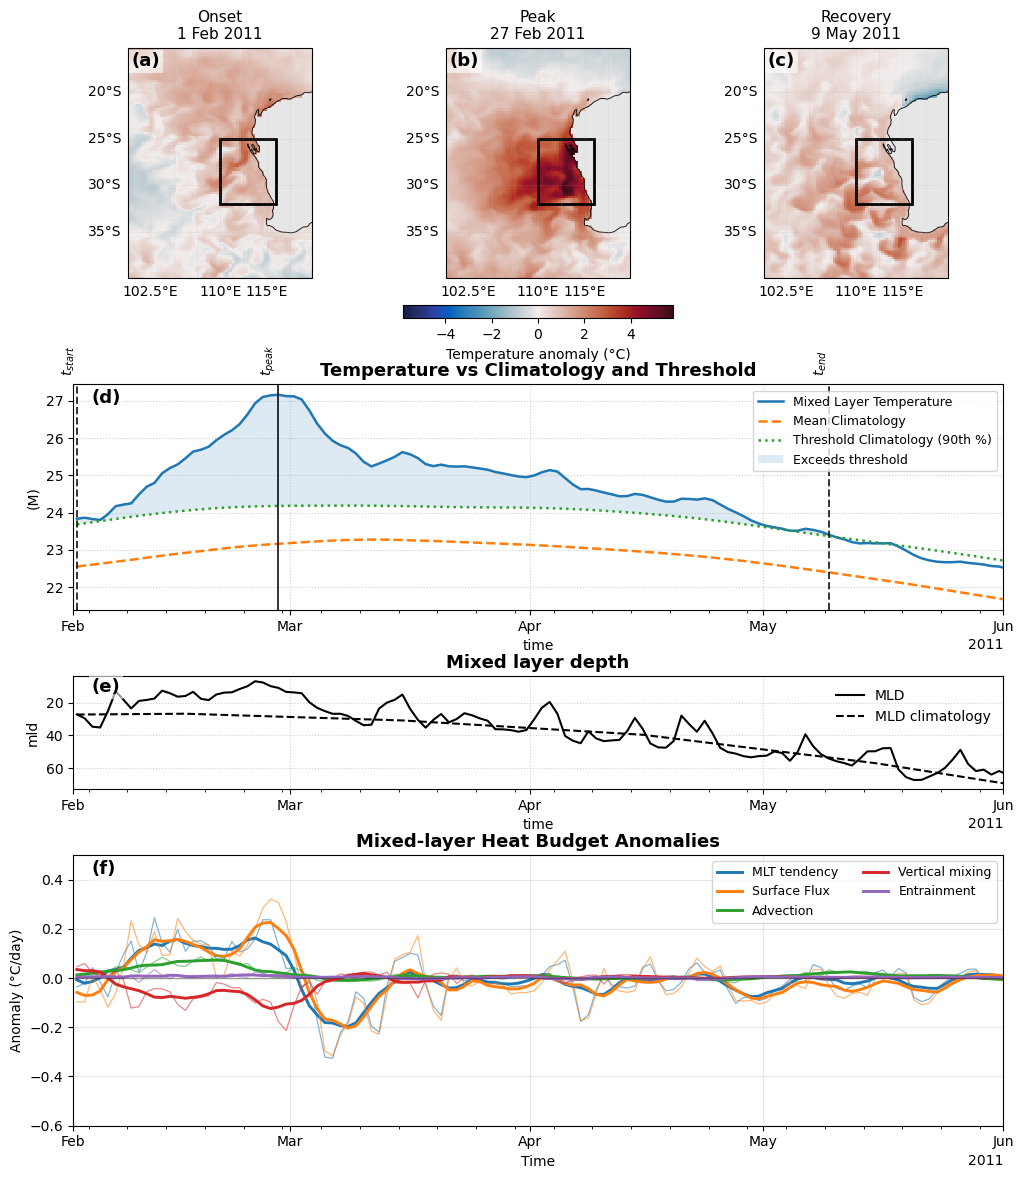

In [32]:
# t_start = '2012-08-01'
# t_peak = '2012-12-01'
# t_end = '2012-02-01'

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(
    nrows=4, ncols=3,
    height_ratios=[1.2, 1.0, 0.5, 1.2],  # maps, temp, MLD (thin), budget
    hspace=0.3, wspace=0.08
)

# -------------------------------------------------------------------
# 1. Three spatial plots of temperature anomaly (onset / peak / recovery)
# -------------------------------------------------------------------

ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)
ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)
ax_map3 = fig.add_subplot(gs[0, 2], projection=proj)
map_axes = [ax_map1, ax_map2, ax_map3]

# Use the main MHW phases found earlier
phase_dates  = [t_start,       t_peak,        t_end]
phase_labels = ['Onset', 'Peak', 'Recovery']

anom_fields = []
for d in phase_dates:
    # day-of-year climatology
    doy = pd.to_datetime(d).dayofyear
    clim_on_date = clim.temp.sel(dayofyear=doy).load()
    temp_on_date = temp.temp.sel(time=d, method='nearest').load()
    anom = (temp_on_date - clim_on_date).load()
    anom_fields.append(anom)

# Symmetric color range across all three anomaly fields
amax = max(float(np.nanmax(np.abs(a.values))) for a in anom_fields)
vmin_anom, vmax_anom = -amax, amax

for ax, anom, phase, d in zip(map_axes, anom_fields, phase_labels, phase_dates):
    try:
        plotmap(anom, ax=ax, lon_name='xt_ocean', lat_name='yt_ocean')
    except TypeError:
        plotmap(anom, ax=ax)

    im = anom.plot.pcolormesh(
        ax=ax, transform=proj,
        cmap=cmo.balance, vmin=vmin_anom, vmax=vmax_anom,
        add_colorbar=False
    )

    # Add black box for sreg region
    sreg_box = Rectangle((sreg[0], sreg[2]), 
                          sreg[1] - sreg[0],  # width
                          sreg[3] - sreg[2],  # height
                          linewidth=2, 
                          edgecolor='black', 
                          facecolor='none',
                          transform=ccrs.PlateCarree())
    ax.add_patch(sreg_box)

    # Title with phase + date
    date_str = pd.to_datetime(d).strftime('%-d %b %Y')
    ax.set_title(f'{phase}\n{date_str}', fontsize=11)

# Shared colourbar for anomaly maps
cbar = fig.colorbar(
    im, ax=map_axes, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.set_label('Temperature anomaly (°C)')

# -------------------------------------------------------------------
# 2. Two-panel time-series: same as cell 22, but slotted under the maps
# -------------------------------------------------------------------

ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[2, :], sharex=ax1)
ax3 = fig.add_subplot(gs[3, :], sharex=ax1)

# ===== TOP PANEL: Temp vs Climatology & Threshold with exceedance =====
temp_mean.plot(ax=ax1, label='Mixed Layer Temperature', linewidth=1.8)
clim_on_time.plot(ax=ax1, label='Mean Climatology', linewidth=1.8, linestyle='--')
thresh_on_time.plot(ax=ax1, label='Threshold Climatology (90th %)', linewidth=1.8, linestyle=':')

t = temp_mean['time'].values
y_temp = temp_mean.to_numpy()
y_thr  = thresh_on_time.to_numpy()
valid  = np.isfinite(y_temp) & np.isfinite(y_thr)

ax1.fill_between(
    t[valid], y_thr[valid], y_temp[valid],
    where=(y_temp[valid] > y_thr[valid]),
    alpha=0.15, label='Exceeds threshold'
)

# ===== Add vertical lines for start, peak and end
times = {
    "start": t_start,
    "peak":  t_peak,
    "end":   t_end,
}

styles = {
    "start": dict(color="k", linestyle="--"),
    "peak":  dict(color="k", linestyle="-"),
    "end":   dict(color="k", linestyle="--"),
}

# Important for xarray: make sure limits exist
ax1.figure.canvas.draw()
ymin, ymax = ax1.get_ylim()

for label, t in times.items():
    ax1.axvline(
        t,
        linewidth=1.4,
        alpha=0.8,
        **styles[label],
    )

    ax1.annotate(
        f"$t_{{{label}}}$",
        xy=(t, ymax),
        xytext=(0, 6),
        textcoords="offset points",
        rotation=90,
        ha="right",
        va="bottom",
        fontsize=10,
    )


# ===== Combine legends from both axes =====
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, fontsize=9, loc="upper left")

ax1.set_title('Temperature vs Climatology and Threshold', fontsize=13, fontweight='bold')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

#====== Add skinny MLD panel
mld_mean.plot(ax=ax2,color='black',label='MLD')
clim_mld_on_time.plot(ax=ax2,color='black',linestyle='--',label='MLD climatology')
ax2.set_title('Mixed layer depth', fontsize=13, fontweight='bold')
ax1.set_ylabel('(M)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.invert_yaxis()
ax2.legend(loc='upper right', frameon=False)

# ===== BOTTOM PANEL: Budget anomalies (same as in cell 22) =====
for i, name in enumerate(order):
    c = colors[i % len(colors)]
    # raw anomaly (thin; no legend)
    anom_win[name].plot(ax=ax3, linewidth=0.9, alpha=0.55, color=c, label='_nolegend_')
    # smoothed anomaly (thick; legend entry)
    anom_smooth_win[name].plot(ax=ax3, linewidth=2.1, color=c, label=name)

ax3.axhline(0, lw=1, color='k', alpha=0.35)
ax3.set_title('Mixed-layer Heat Budget Anomalies', fontsize=13, fontweight='bold')
ax3.set_ylabel('Anomaly (°C/day)')
ax3.set_ylim([-.6, .5])
ax3.grid(True, alpha=0.3)

# Shared x-axis formatting for both TS panels
ax3.set_xlim(pd.Timestamp(t0), pd.Timestamp(t1))
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax3.xaxis.set_minor_locator(mdates.DayLocator(interval=5))
ax3.xaxis.set_minor_formatter(NullFormatter())
ax3.set_xlabel('Time')

ax3.legend(ncol=2, fontsize=9)
# -------------------------------------------------------------------
# Add panel labels: (a), (b), (c), ...
# -------------------------------------------------------------------

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)','(f)']
axes_to_label = [ax_map1, ax_map2, ax_map3, ax1, ax2, ax3]

for ax, label in zip(axes_to_label, panel_labels):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=13, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
    )
#fig.suptitle('TAS MHW: Anomaly Maps and Mixed-layer Heat Budget', y=0.995, fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.97])

# Optional: save to file
#plt.savefig("/home/561/nm5072/access-om2-sst-budget/TAS_MHW_combined_figure.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
#plt.savefig("/home/561/nm5072/access-om2-sst-budget/WA_MHW_coastal_combined_figure.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.savefig("/home/561/nm5072/access-om2-sst-budget/WA_MHW_combined_figure.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
#plt.savefig("/home/561/nm5072/access-om2-sst-budget/SO_MHW_combined_figure.png", dpi=300, bbox_inches="tight", pad_inches=0.1)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

# ---- compute closure: LHS - RHS ----
rhs_terms = [name for name in order if name != 'MLT tendency']

closure = anom_win['MLT tendency']
for name in rhs_terms:
    closure = closure - anom_win[name]

# ---- plot closure ----
closure.plot(
    ax=ax,
    color='k',
    linewidth=2.8,
    linestyle='--',
    label='Closure (MLT tendency − sum RHS)'
)

# ---- cosmetics ----
ax.axhline(0, color='k', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Temperature tendency anomaly (°C/day)')
ax.set_title('Mixed-layer heat budget anomaly closure')
ax.legend(ncol=2)
ax.grid(True)


In [23]:
mld_mean.plot(ax=ax2,color='black')
clim_mld_on_time.plot(ax=ax2,color='black',linestyle='--')

(array([1.4704e+04, 3.7110e+04, 1.3401e+04, 4.6460e+03, 1.1430e+03,
        4.6100e+02, 2.1800e+02, 9.9000e+01, 5.9000e+01, 3.3000e+01]),
 array([  9.42361456,  27.7259997 ,  46.02838484,  64.33076998,
         82.63315512, 100.93554026, 119.2379254 , 137.54031054,
        155.84269568, 174.14508082, 192.44746596]),
 <BarContainer object of 10 artists>)

In [ ]:
mld_tseries= ds_day.mld.sel(xt_ocean=slice(sreg[0],sreg[1]),yt_ocean=slice(sreg[2],sreg[3])).mean(dim=['yt_ocean','xt_ocean'])

In [ ]:
mld_tseries

In [24]:
clim_mld_on_time

<xarray.DataArray 'mld' (time: 121, yt_ocean: 32, xt_ocean: 24)> Size: 743kB
array([[[28.62029869, 29.21309705, 29.54174214, ..., 16.76091625,
         15.55999451,         nan],
        [28.58345838, 29.72993131, 30.23127734, ..., 13.34410963,
         17.16647893,         nan],
        [28.96520042, 30.15735774, 30.74724628, ..., 18.38853104,
                 nan,         nan],
        ...,
        [24.25569116, 24.61451247, 24.63220775, ...,         nan,
                 nan,         nan],
        [24.10355469, 24.24383853, 24.18550128, ...,         nan,
                 nan,         nan],
        [23.94121613, 24.02815511, 23.8396751 , ...,         nan,
                 nan,         nan]],

       [[28.70364368, 29.32010214, 29.64036529, ..., 16.74874706,
         15.56172436,         nan],
        [28.67534773, 29.84954397, 30.34016271, ..., 13.39290157,
         17.17166679,         nan],
        [29.06813049, 30.27968462, 30.85269565, ..., 18.39263141,
                 nan,         nan],
...
        [57.97236153, 57.35840311, 55.83973165, ...,         nan,
                 nan,         nan],
        [58.10366108, 57.00005636, 57.09119846, ...,         nan,
                 nan,         nan],
        [57.55365076, 58.52717233, 57.27350444, ...,         nan,
                 nan,         nan]],

       [[88.56010732, 85.88510107, 85.37440614, ..., 57.5205782 ,
         21.09464079,         nan],
        [87.26961493, 83.45444415, 82.71568077, ..., 45.21680266,
         21.19436547,         nan],
        [86.12016641, 82.86473133, 81.19091526, ..., 32.28466895,
                 nan,         nan],
        ...,
        [58.59413615, 57.97914763, 56.4645494 , ...,         nan,
                 nan,         nan],
        [58.7519012 , 57.69811372, 57.76934199, ...,         nan,
                 nan,         nan],
        [58.22211333, 59.25608137, 57.905665  , ...,         nan,
                 nan,         nan]]], shape=(121, 32, 24))
Coordinates:
  * time       (time) datetime64[ns] 968B 2011-02-01T12:00:00 ... 2011-06-01T...
  * yt_ocean   (yt_ocean) float64 256B -31.85 -31.63 -31.42 ... -25.26 -25.04
  * xt_ocean   (xt_ocean) float64 192B -249.9 -249.6 -249.4 ... -244.4 -244.1
    dayofyear  (time) int64 968B 32 33 34 35 36 37 ... 147 148 149 150 151 152